In [11]:
import numpy as np
import matplotlib.pyplot as plt
import natural_units as nu

output_tag = '20251029'
output_file = '../test/initial/' + output_tag + '/result-' + output_tag + '.txt'

rho_s = 1.28e7 * nu.mSun / nu.kpc**3
r_s = 6.5 * nu.kpc
t_fid = np.power(4 * np.pi * nu.G_Newton * rho_s ,-1/2)

In [12]:
def _decade_bounds(vmin, vmax):
    """给定正数范围，返回包含它们的整十次幂上下界 kmin, kmax（log10 空间的整数）"""
    if vmin <= 0 or vmax <= 0:
        raise ValueError("log 轴范围必须为正数")
    kmin = int(np.floor(np.log10(vmin)))
    kmax = int(np.ceil (np.log10(vmax)))
    if kmin == kmax:  # 避免退化：只有一个十倍数区间时扩一点
        kmin -= 1
        kmax += 1
    return kmin, kmax

def _make_log_ticks(vmin, vmax):
    """
    自动生成 log 轴的主/次刻度：
    - 主刻度：10^k
    - 次刻度：m*10^k, m=2..9
    返回：(positions_log10, labels_str, minor_positions_log10)
    """
    kmin, kmax = _decade_bounds(vmin, vmax)
    majors = []
    minors = []
    for k in range(kmin, kmax + 1):
        majors.append(10.0**k)
        for m in range(2, 10):  # 2..9
            minors.append(m * 10.0**k)
    # 仅保留在范围内的
    majors = [x for x in majors if vmin <= x <= vmax]
    minors = [x for x in minors if vmin <= x <= vmax]
    # 位置映射到 log10 空间
    major_pos = np.log10(majors) if majors else []
    minor_pos = np.log10(minors) if minors else []
    # 标签：主刻度显示 1e±k，次刻度不标（避免乱）
    major_lbl = [f"1e{int(np.log10(x))}" for x in majors]
    return major_pos, major_lbl, minor_pos


def read_output(filename):
    data_blocks = []
    with open(filename, 'r') as f:
        lines = f.readlines()

    # 跳过开头的说明文字，找到 "time, step, ..." 之后
    start_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith("time, step"):
            start_idx = i + 1
            break
    if start_idx is None:
        raise ValueError("找不到数据开头标记")

    i = start_idx
    while i < len(lines):
        # 1. 时间和步数
        parts = lines[i].split()
        if len(parts) < 2:
            break
        time = float(parts[0])
        step = int(parts[1])
        i += 1

        # 2. 六个数组
        RList  = np.fromstring(lines[i], sep=' '); i += 1
        RhoList= np.fromstring(lines[i], sep=' '); i += 1
        MList  = np.fromstring(lines[i], sep=' '); i += 1
        uList  = np.fromstring(lines[i], sep=' '); i += 1
        LList  = np.fromstring(lines[i], sep=' '); i += 1
        CList  = np.fromstring(lines[i], sep=' '); i += 1

        block = {
            "time": time,
            "step": step,
            "R": RList,
            "rho": RhoList,
            "M": MList,
            "u": uList,
            "L": LList,
            "C": CList
        }
        data_blocks.append(block)

    return data_blocks

In [13]:
blocks = read_output(output_file)
print("读到 %d 个时间片" % len(blocks))

读到 16863 个时间片


/var/folders/9v/y06d7lqs27q0yn2p9g1ttwp80000gn/T/ipykernel_37735/4016655153.py:3: RuntimeWarning: invalid value encountered in log10
  x   = np.log10(datapoint["R"] * r_s / nu.kpc)
/var/folders/9v/y06d7lqs27q0yn2p9g1ttwp80000gn/T/ipykernel_37735/4016655153.py:5: RuntimeWarning: invalid value encountered in log10
  z = np.log10(datapoint["rho"] * rho_s / nu.mSun * nu.kpc**3)
/var/folders/9v/y06d7lqs27q0yn2p9g1ttwp80000gn/T/ipykernel_37735/4016655153.py:50: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


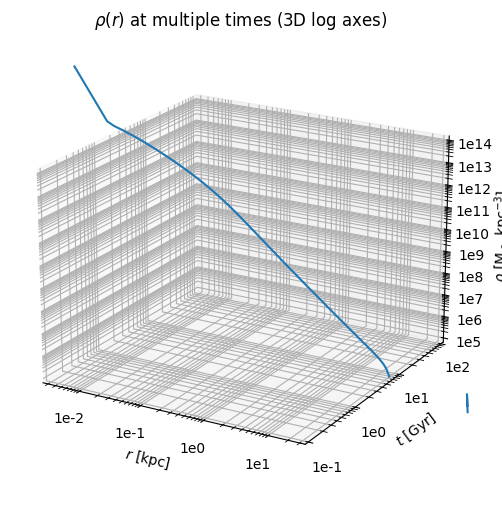

In [28]:
datapoint = blocks[-1]

x   = np.log10(datapoint["R"] * r_s / nu.kpc)
y   = np.log10(np.full_like(x, datapoint["time"] * t_fid / 1e9 / nu. year))
z = np.log10(datapoint["rho"] * rho_s / nu.mSun * nu.kpc**3)

xmin = 3e-3
xmax = 3e1
ymin = 1e-1
ymax = 1e2
zmin = 1e5
zmax = 1e14
xmaj, xlbl, xminr = _make_log_ticks(xmin, xmax)
ymaj, ylbl, yminr = _make_log_ticks(ymin, ymax)
zmaj, zlbl, zminr = _make_log_ticks(zmin, zmax)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(projection='3d')

ax.plot(x, y, z)

ax.set_xlim(np.log10(xmin), np.log10(xmax))
ax.set_ylim(np.log10(ymin), np.log10(ymax))
ax.set_zlim(np.log10(zmin), np.log10(zmax))

# 设置主刻度位置与标签（标签显示原始值）
ax.set_xticks(xmaj); ax.set_xticklabels(xlbl)
ax.set_yticks(ymaj); ax.set_yticklabels(ylbl)
ax.set_zticks(zmaj); ax.set_zticklabels(zlbl)

# 设置次刻度（不打标签）
# 3DAxes 支持 minor ticks，但不会自动画，需要手动启用
ax.set_xticks(xminr, minor=True)
ax.set_yticks(yminr, minor=True)
ax.set_zticks(zminr, minor=True)

# 打开次刻度可见性（不同后端可能需要调整）
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.set_tick_params(which='minor', length=3)   # 次刻度短
    axis.set_tick_params(which='major', length=6)   # 主刻度长

ax.grid(True, which='major')
ax.set_xlabel(r"$r$ [kpc]")     # 改成你的单位
ax.set_ylabel(r"$t$ [Gyr]")
ax.set_zlabel(r"$\rho$ [M$_\odot$ kpc$^{-3}$]")
ax.set_title(r"$\rho(r)$ at multiple times (3D log axes)")
# 设置观察角度
ax.view_init(elev=20)

plt.tight_layout()
plt.show()